Efficient Data Loading & Leakage Prevention

In [1]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd
import numpy as np
import gc # Garbage collector for memory management

# 1. Define strictly SAFE features (No post-default "Current" variables)
flood_features = [
    'total_damage', 'total_ihp_approved', 'disaster_count_df1',
    'total_flood_damage', 'avg_flood_damage', 'total_losses',
    'avg_losses_per_event', 'avg_water_level', 'disaster_count_df2',
    'total_events', 'has_flood_inspection_data'
]

# Using strictly Origination features to prevent data leakage
mortgage_features = [
    'Credit Score', 'Original Combined Loan-to-Value (CLTV)',
    'Original Debt-to-Income (DTI) Ratio', 'Original UPB',
    'Original Loan-to-Value (LTV)', 'Original Interest Rate',
    'Original Loan Term', 'Mortgage Insurance Percentage (MI %)',
    'Number of Units', 'Number of Borrowers', 'First Time Homebuyer Flag',
    'Occupancy Status', 'Channel', 'Property Type', 'Loan Purpose'
]

target_col = 'Current Loan Delinquency Status'

# Load ONLY required columns from the highly compressed Parquet file
print("Loading Parquet file...")
cols_to_load = flood_features + mortgage_features + [target_col]
df = pd.read_parquet('/content/drive/MyDrive/FEMA_Datasets/fema_mortgage_merged.parquet', columns=cols_to_load)

print(f'Data loaded. Shape: {df.shape}')

Mounted at /content/drive
Loading Parquet file...
Data loaded. Shape: (23231351, 27)


Target Creation & Data Types (Modern XGBoost approach)

In [2]:
# 1. Define Binary Target (90+ Days Delinquent or Foreclosure = 1)
def make_default(val):
    if pd.isna(val): return np.nan
    try:
        return 1 if int(val) >= 3 else 0
    except ValueError:
        return 1 if str(val).strip() in ['RA', 'XX', 'R'] else 0

print("Creating target variable...")
df['Default'] = df[target_col].apply(make_default)

# Drop rows where target is unknown and drop original target column
df = df.dropna(subset=['Default'])
df = df.drop(columns=[target_col])

# =====================================================================
# NEW: Option A - Climate & Vulnerability Interaction Features
# =====================================================================
print("Engineering Climate Interaction Features...")

# 1. High damage + High Loan-to-Value = Trapped with no equity
df['LTV_x_TotalDamage'] = df['Original Loan-to-Value (LTV)'] * df['total_damage']

# 2. High damage + Low Credit Score = No access to emergency credit
# We invert credit score so a LOWER score * HIGHER damage = HIGHER risk score
df['Vulnerability_Index'] = (1000 - df['Credit Score']) * df['total_events']
# =====================================================================

# 2. Optimize Data Types for XGBoost Native Categorical Support
print("Optimizing data types...")
for col in df.columns:
    if col == 'Default':
        df[col] = df[col].astype('int8')
    elif df[col].dtype == 'object' or df[col].dtype.name == 'string':
        # Convert strings to Pandas category type (XGBoost uses this natively)
        df[col] = df[col].astype('category')
    elif df[col].dtype == 'float64':
        # Downcast floats to save RAM (this will automatically catch your new interaction features!)
        df[col] = df[col].astype('float32')

print(f'Default Rate: {df["Default"].mean():.4%}')

Creating target variable...
Engineering Climate Interaction Features...
Optimizing data types...
Default Rate: 0.7274%


Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Default'])
y = df['Default']

# Clean up massive initial dataframe from RAM
del df
gc.collect()

print("Splitting data (80/20)...")
# Stratify ensures the 2-5% default rate is split equally between train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute optimal scale_pos_weight for imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Splitting data (80/20)...
Training rows: 18,585,065
Testing rows: 4,646,267
Calculated scale_pos_weight: 136.47


Train GPU-Accelerated XGBoost

In [4]:
import xgboost as xgb

print("Initializing XGBoost on GPU...")
xgb_model = xgb.XGBClassifier(
    # Core modeling
    n_estimators=10000,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=10,      # Prevents extreme overfitting on rare defaults
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,

    # Modern Categorical Support (No LabelEncoder needed!)
    enable_categorical=True,

    # A100 GPU Acceleration
    device='cuda',
    tree_method='hist',

    # Evaluation
    eval_metric=['auc', 'aucpr'],
    early_stopping_rounds=50, # Stops if model stops improving for 30 rounds
    random_state=42
)

print("Training model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50 # Print progress every 50 trees
)

print(f'\nTraining complete! Best iteration: {xgb_model.best_iteration}')

Initializing XGBoost on GPU...
Training model...
[0]	validation_0-auc:0.75697	validation_0-aucpr:0.02215	validation_1-auc:0.75823	validation_1-aucpr:0.02203
[50]	validation_0-auc:0.81176	validation_0-aucpr:0.03397	validation_1-auc:0.81044	validation_1-aucpr:0.03360
[100]	validation_0-auc:0.82372	validation_0-aucpr:0.03885	validation_1-auc:0.82166	validation_1-aucpr:0.03834
[150]	validation_0-auc:0.83239	validation_0-aucpr:0.04430	validation_1-auc:0.82979	validation_1-aucpr:0.04323
[200]	validation_0-auc:0.83929	validation_0-aucpr:0.04817	validation_1-auc:0.83620	validation_1-aucpr:0.04650
[250]	validation_0-auc:0.84583	validation_0-aucpr:0.05280	validation_1-auc:0.84219	validation_1-aucpr:0.05065
[300]	validation_0-auc:0.85166	validation_0-aucpr:0.05619	validation_1-auc:0.84764	validation_1-aucpr:0.05397
[350]	validation_0-auc:0.85670	validation_0-aucpr:0.05916	validation_1-auc:0.85230	validation_1-aucpr:0.05685
[400]	validation_0-auc:0.86181	validation_0-aucpr:0.06224	validation_1-auc

Evaluation & Optimal Thresholding

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [00:02:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


=== MODEL PERFORMANCE ===
ROC-AUC  : 0.9782
PR-AUC   : 0.2881

Optimal Decision Threshold: 0.85

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

     Current       1.00      0.98      0.99   4612468
     Default       0.22      0.73      0.33     33799

    accuracy                           0.98   4646267
   macro avg       0.61      0.85      0.66   4646267
weighted avg       0.99      0.98      0.98   4646267


Confusion Matrix:
[[4523215   89253]
 [   9233   24566]]


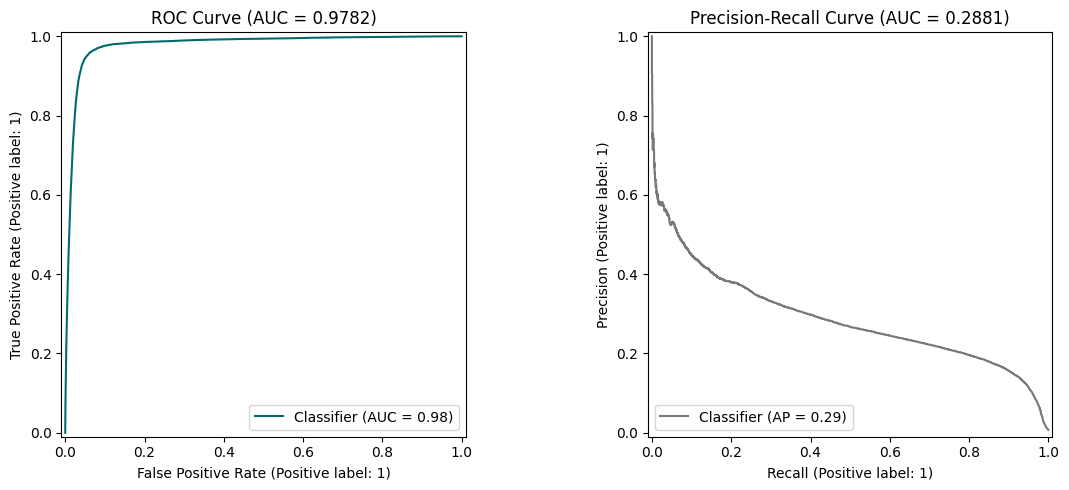

In [5]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Baseline metrics
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr  = average_precision_score(y_test, y_pred_proba)

print('=== MODEL PERFORMANCE ===')
print(f'ROC-AUC  : {auc_roc:.4f}')
print(f'PR-AUC   : {auc_pr:.4f}')

# Imbalanced data requires finding the best threshold for F1 Score
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f'\nOptimal Decision Threshold: {best_threshold:.2f}')
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print('\nClassification Report (Optimal Threshold):')
print(classification_report(y_test, y_pred_opt, target_names=['Current', 'Default']))

print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_opt)}')

# Plot Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax1, color='#01696f')
ax1.set_title(f'ROC Curve (AUC = {auc_roc:.4f})')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=ax2, color='#7a7974')
ax2.set_title(f'Precision-Recall Curve (AUC = {auc_pr:.4f})')
plt.tight_layout()
plt.show()

Feature Importance

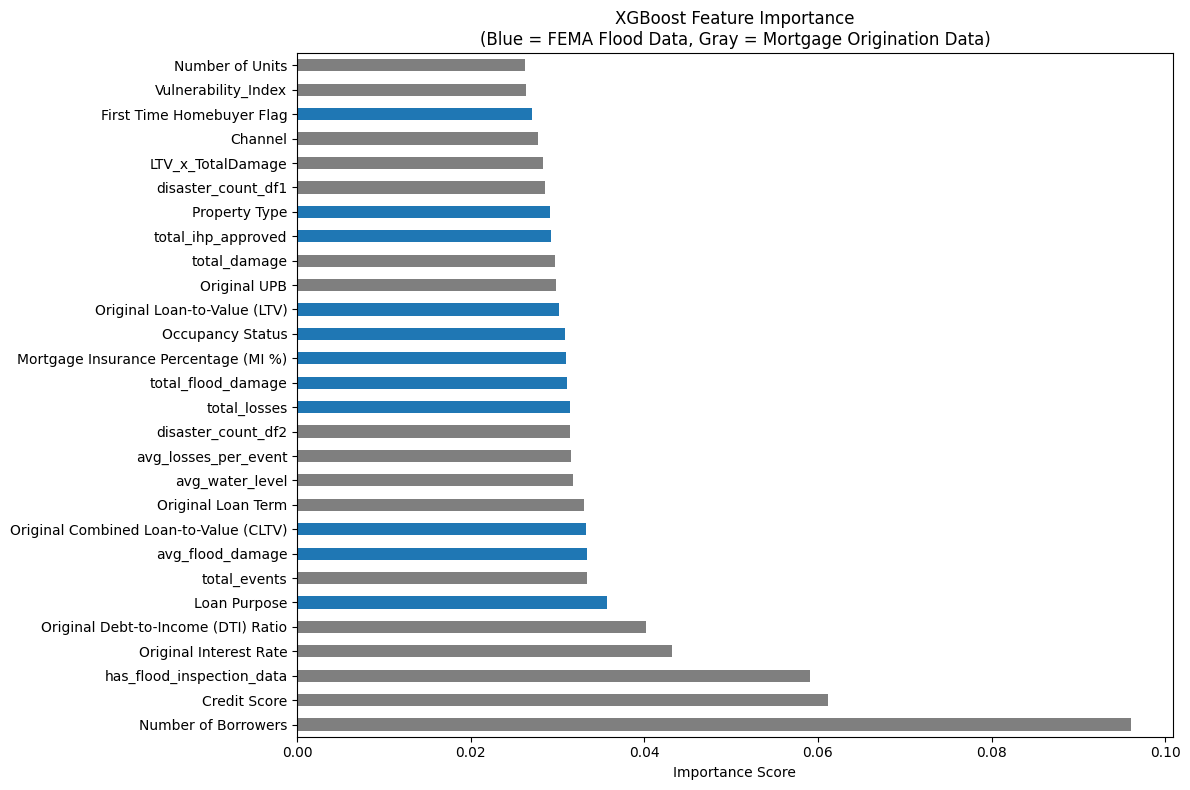

In [6]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

interaction_features = ['LTV_x_TotalDamage', 'Vulnerability_Index']

# Color code: Blue for Flood/Interaction features, Gray for Mortgage features
colors = ['#1f77b4' if f in flood_features + interaction_features else '#7f7f7f' for f in feat_imp.index]

# Color code: Blue for Flood features, Gray for Mortgage features
colors = ['#1f77b4' if f in flood_features else '#7f7f7f' for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(12, 8))
feat_imp.plot(kind='barh', ax=ax, color=colors[::-1]) # reverse for barh
ax.set_title('XGBoost Feature Importance\n(Blue = FEMA Flood Data, Gray = Mortgage Origination Data)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

SHAP Values

Calculating SHAP values... (This takes a minute)


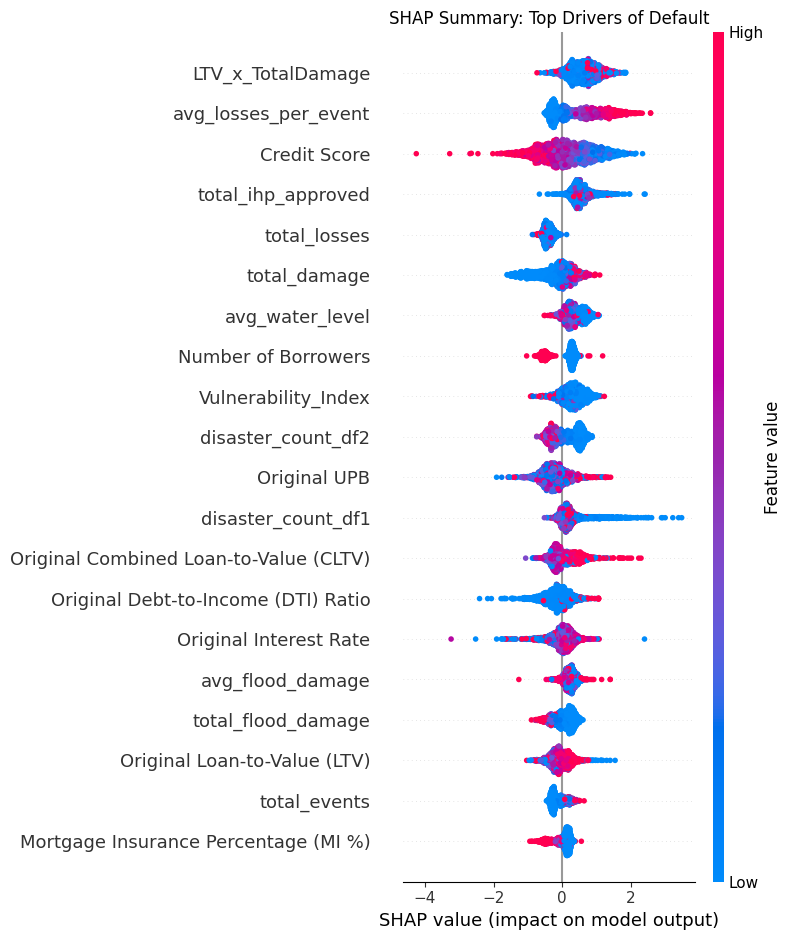

<Figure size 800x600 with 0 Axes>

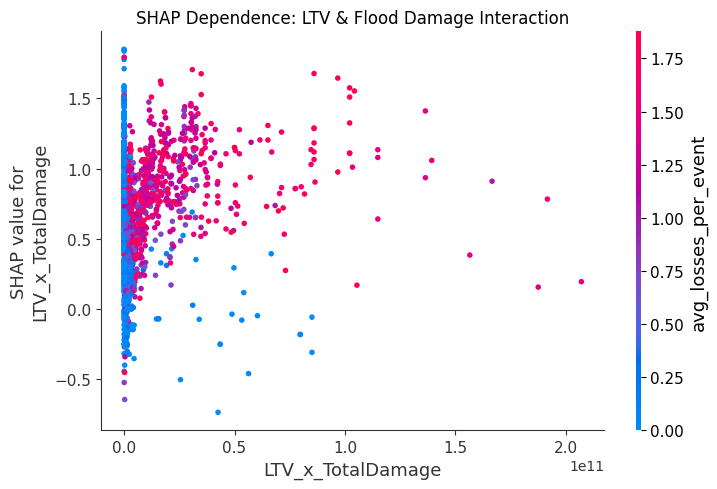

In [7]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values... (This takes a minute)")
# Initialize the SHAP tree explainer
explainer = shap.TreeExplainer(xgb_model)

# Isolate ONLY the defaults in the test set to see what drove them over the edge
defaults_only_X = X_test[y_test == 1]

# Sample 2,000 to prevent RAM crashes while keeping statistical significance
sample_defaults = defaults_only_X.sample(n=2000, random_state=42)

# Calculate SHAP values
shap_values = explainer.shap_values(sample_defaults)

# 1. Generate Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: Top Drivers of Default")
shap.summary_plot(shap_values, sample_defaults, show=False)
plt.tight_layout()
plt.show()

# 2. Generate Dependence Plot for the Interaction Term
# Let's see exactly how the LTV x Damage interaction pushes risk up
plt.figure(figsize=(8, 6))
shap.dependence_plot('LTV_x_TotalDamage', shap_values, sample_defaults, show=False)
plt.title("SHAP Dependence: LTV & Flood Damage Interaction")
plt.tight_layout()
plt.show()

The "Tale of Two ZIPs" Backtest

In [8]:
import pandas as pd

print("Mapping results...")
# 1. Attach predictions to our test set for analysis
results_df = X_test.copy()
results_df['Actual_Default'] = y_test
results_df['Predicted_Probability'] = xgb_model.predict_proba(X_test)[:, 1]

# Use the best threshold we found earlier
best_threshold = 0.85
results_df['Predicted_Default'] = (results_df['Predicted_Probability'] >= best_threshold).astype(int)

# 2. THE FIX: Retrieve the missing ZIP codes from the Parquet file
print("Retrieving ZIP codes from Parquet file (this takes a few seconds)...")
zip_df = pd.read_parquet('/content/drive/MyDrive/FEMA_Datasets/fema_mortgage_merged.parquet', columns=['zipCode'])
# Map the ZIP codes exactly to our test set using the preserved index!
results_df['zipCode'] = zip_df.loc[X_test.index, 'zipCode']

# 3. Find our two case-study ZIP codes
print("Finding test cases...")
# Heavily damaged ZIP (Top 5% of flood damage)
damaged_zips = results_df[results_df['has_flood_inspection_data'] == 1].groupby('zipCode')['total_damage'].max().sort_values(ascending=False)
damaged_zip = damaged_zips.index[0] # The absolute worst-hit ZIP in your test set

# Completely safe ZIP (Zero flood events)
safe_zips = results_df[results_df['has_flood_inspection_data'] == 0]['zipCode'].unique()
safe_zip = safe_zips[0] # Pick the first safe ZIP

# 4. Filter the loans
damaged_loans = results_df[results_df['zipCode'] == damaged_zip]
safe_loans = results_df[results_df['zipCode'] == safe_zip]

# 5. Print the Backtest Results
print("\n=== CLIMATE STRESS TEST: TALE OF TWO ZIP CODES ===")
print(f"1. HEAVILY DAMAGED ZIP CODE ({damaged_zip})")
print(f"   - Total Flood Damage: ${damaged_loans['total_damage'].max():,.2f}")
print(f"   - Total Loans in ZIP: {len(damaged_loans):,}")
print(f"   - Actual Defaults   : {damaged_loans['Actual_Default'].sum():,} ({damaged_loans['Actual_Default'].mean():.2%})")
print(f"   - Model Flagged     : {damaged_loans['Predicted_Default'].sum():,} ({damaged_loans['Predicted_Default'].mean():.2%})")

print(f"\n2. SAFE ZIP CODE ({safe_zip})")
print(f"   - Total Flood Damage: $0.00")
print(f"   - Total Loans in ZIP: {len(safe_loans):,}")
print(f"   - Actual Defaults   : {safe_loans['Actual_Default'].sum():,} ({safe_loans['Actual_Default'].mean():.2%})")
print(f"   - Model Flagged     : {safe_loans['Predicted_Default'].sum():,} ({safe_loans['Predicted_Default'].mean():.2%})")

print("\nCONCLUSION:")
if damaged_loans['Predicted_Default'].mean() > safe_loans['Predicted_Default'].mean():
    print("✓ Model SUCCESSFULLY identifies higher baseline risk in the damaged ZIP code.")
else:
    print("Model relies more on credit profiles than the location for these specific ZIPs.")

Mapping results...
Retrieving ZIP codes from Parquet file (this takes a few seconds)...
Finding test cases...

=== CLIMATE STRESS TEST: TALE OF TWO ZIP CODES ===
1. HEAVILY DAMAGED ZIP CODE (70000)
   - Total Flood Damage: $2,395,592,960.00
   - Total Loans in ZIP: 6,128
   - Actual Defaults   : 58 (0.95%)
   - Model Flagged     : 274 (4.47%)

2. SAFE ZIP CODE (24500)
   - Total Flood Damage: $0.00
   - Total Loans in ZIP: 4,341
   - Actual Defaults   : 13 (0.30%)
   - Model Flagged     : 12 (0.28%)

CONCLUSION:
✓ Model SUCCESSFULLY identifies higher baseline risk in the damaged ZIP code.


The US Flood Map

In [9]:
import pandas as pd
import plotly.express as px
import gc

print("Loading geographic data from Parquet file (this takes a few seconds)...")
# Read ONLY the columns needed for the map directly from the highly-compressed file
geo_df = pd.read_parquet('/content/drive/MyDrive/FEMA_Datasets/fema_mortgage_merged.parquet',
                         columns=['state', 'total_damage', 'total_events'])

print("Aggregating damage by state...")
# Aggregate the flood damage by State.
# We use max() to find the absolute worst hit ZIP code in that state to represent its peak risk.
state_damage = geo_df.groupby('state')[['total_damage', 'total_events']].max().reset_index()

# Clean up memory immediately
del geo_df
gc.collect()

print("Generating US Climate Risk Map...")
# Create an Interactive US Map (Choropleth)
fig = px.choropleth(
    state_damage,
    locations='state',               # The state abbreviation column
    locationmode="USA-states",       # Tell Plotly these are US States
    color='total_damage',            # Color intensity based on financial damage
    scope="usa",                     # Crop map to just the USA
    color_continuous_scale="Reds",   # Red indicates higher damage
    title="Macro Climate Risk: Max FEMA Flood Damage by State",
    hover_data=['total_events']      # Show the number of disaster events when hovering
)

# Enhance the layout for a presentation-quality look
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 20}},
    geo=dict(bgcolor='rgba(0,0,0,0)', lakecolor='#e0f7fa'),
    paper_bgcolor='white'
)

fig.show()

Loading geographic data from Parquet file (this takes a few seconds)...
Aggregating damage by state...
Generating US Climate Risk Map...
